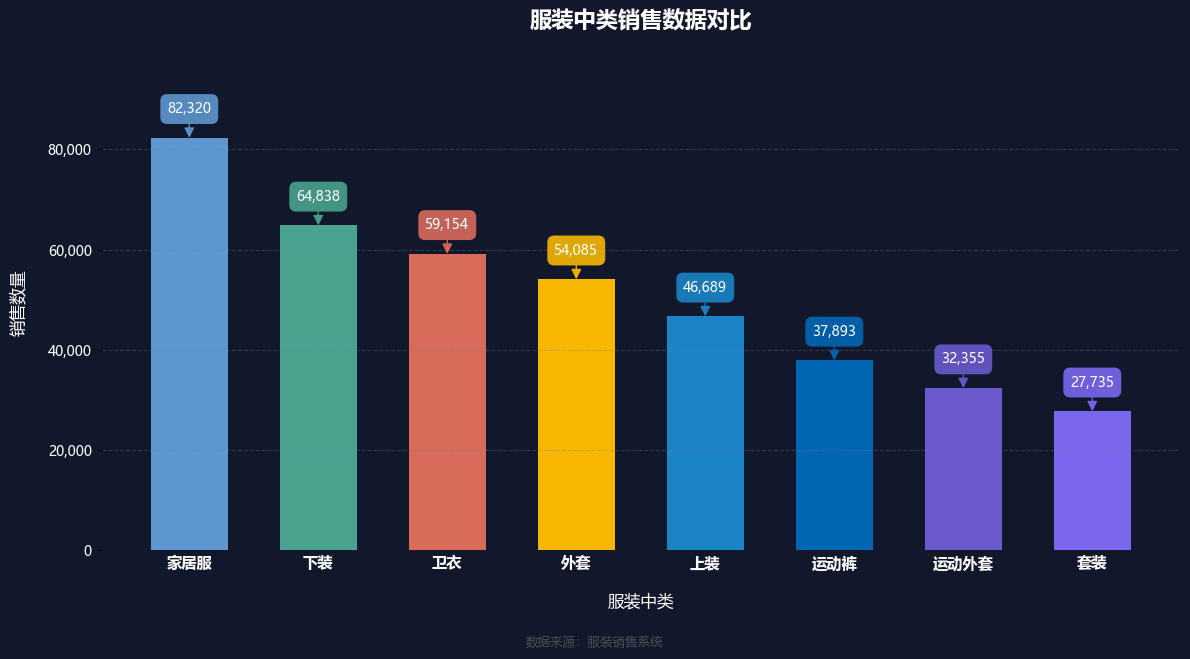

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial']
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

try:
    # 读取生成的数据
    spu_data = pd.read_csv('../../spu_manages_feishu.csv', encoding='utf-8-sig')
    
    # 检查必要的列是否存在
    required_columns = ['中类', '销售数量']
    for col in required_columns:
        if col not in spu_data.columns:
            raise ValueError(f"数据中缺少必要列: {col}")
    
    # 数据清洗
    if spu_data['中类'].isnull().all() or spu_data['销售数量'].isnull().all():
        raise ValueError("中类或销售数量数据全部为空")
    
    # 清洗无效数据
    spu_data = spu_data[spu_data['中类'].notnull() & spu_data['销售数量'].notnull()]
    if spu_data.empty:
        raise ValueError("没有有效的中类或销售数量数据")
    
    # 按中类汇总销售数据
    category_sales = spu_data.groupby('中类')['销售数量'].sum().reset_index()
    category_sales = category_sales.sort_values('销售数量', ascending=False).head(8)
    
    # 创建自定义颜色映射（参考图片样式）
    colors = [
        '#5e97d0',  # 浅蓝色
        '#4aa38f',  # 青绿色
        '#d96b5a',  # 橙红色
        '#f7b700',  # 金色
        '#1a84c7',  # 亮蓝色
        '#0066b3',  # 深蓝色
        '#6a5acd',  # 紫色
        '#7b68ee'   # 浅紫色
    ]
    
    # 创建深色背景的图表
    fig, ax = plt.subplots(figsize=(12, 7), dpi=100)
    fig.patch.set_facecolor('#12182B')  # 深蓝色背景
    ax.set_facecolor('#12182B')
    
    # 绘制柱形图
    bars = ax.bar(
        category_sales['中类'],
        category_sales['销售数量'],
        color=colors,
        edgecolor='none',
        width=0.6
    )
    
    # 设置Y轴
    ax.set_ylim(0, max(category_sales['销售数量']) * 1.2)
    ax.set_yticks(np.arange(0, max(category_sales['销售数量']) * 1.2, 2000))
    ax.set_yticklabels([f'{int(x):,}' for x in np.arange(0, max(category_sales['销售数量']) * 1.2, 2000)], 
                      color="#ffffff", fontsize=10)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.grid(axis='y', linestyle='--', alpha=0.3, color='#1a1e43')
    
    # 移除边框
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    # 设置X轴标签
    ax.set_xticks(range(len(category_sales)))
    ax.set_xticklabels(category_sales['中类'], color="#ffffff", fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', length=0)
    
    # 添加数据标注
    for i, bar in enumerate(bars):
        height = bar.get_height()
        value = int(height)
        
        # 创建带尖角的标注框
        box_style = "round,pad=0.5,rounding_size=0.5"
        bbox = dict(
            boxstyle=box_style,
            facecolor=colors[i],
            edgecolor='none',
            alpha=0.9
        )
        
        # 添加标注
        ax.annotate(
            f'{value:,}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 15),  # 偏移量
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=10,
            color='white',
            bbox=bbox,
            arrowprops=dict(
                arrowstyle='-|>',
                shrinkA=0,
                shrinkB=0,
                fc=colors[i],
                ec=colors[i],
                alpha=0.9,
                mutation_scale=15
            )
        )
    
    # 添加标题和标签
    plt.title('服装中类销售数据对比', fontsize=16, fontweight='bold', color="#ffffff", pad=20)
    plt.ylabel('销售数量', fontsize=12, color="#ffffff", labelpad=15)
    plt.xlabel('服装中类', fontsize=12, color="#ffffff", labelpad=15)
    
    # 添加网格线
    ax.yaxis.grid(True, linestyle='--', alpha=0.3, color="#777b92")
    
    # 添加底部装饰
    plt.figtext(0.5, 0.02, 
                f'数据来源：服装销售系统', 
                ha='center', 
                fontsize=9, 
                color='#666666',
                alpha=0.7)
    
    # 修复rect参数类型问题 - 使用元组而不是列表
    plt.tight_layout(rect=(0.0, 0.05, 1.0, 0.95))
    
    # 保存高清图片
    plt.savefig('服装中类销售数据对比.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    
    plt.show()

except Exception as e:
    print(f"图表生成失败: {str(e)}")
    raise

# 分析

- **最高销售量**：家居服的销售数量最高，达到82,320件，显著高于其他类别，表明家居服在市场中的需求较大。

- **次高销售量**：下装的销售数量为64,838件，位居第二，显示出较强的市场需求。

- **中等销售量**：卫衣（59,154件）、外套（54,085件）、上装（46,689件）的销售数量处于中等水平，显示出稳定的市场需求。

- **较低销售量**：运动裤（37,893件）、运动外套（32,355件）和套装（27,735件）的销售数量相对较低，可能表明这些类别的市场需求较弱或竞争较为激烈。


# 结论
该图表为服装市场的销售分析提供了直观的数据支持。家居服和下装的高销售量可能指示了消费者对舒适性和多样性的需求，而运动裤、运动外套和套装的低销售量则可能需要进一步的市场调研来了解原因，以便制定相应的市场策略。